# Fine-Tuning SAM com LoRA para Segmentação de Órgãos em Chest CT

Este notebook implementa um pipeline completo de fine-tuning do Segment Anything Model (SAM) usando:
- **LoRA (Low-Rank Adaptation)**: Para treinar apenas ~0.13% dos parâmetros
- **Dataset**: Chest CT Segmentation (Lung, Heart, Trachea combinados em máscara binária)
- **Dice + Focal Loss**: Para segmentação precisa
- **Early Stopping e Checkpointing**: Para melhor modelo

## 1. Instalação de Dependências


In [1]:
%pip install -q segment-anything albumentations pycocotools opencv-python matplotlib torch torchvision kagglehub tqdm


## 2. Download do Dataset e Modelo


In [2]:
import kagglehub
import os
import pandas as pd

# Download dataset de chest CT segmentation
try:
    path = kagglehub.dataset_download("polomarco/chest-ct-segmentation")
    print(f"Dataset path: {path}")
except Exception as e:
    print(f"Erro no download: {e}")
    path = '/kaggle/input/chest-ct-segmentation'

# Estrutura do dataset: images/, masks/, train.csv
images_dir = os.path.join(path, "images", "images")
masks_dir = os.path.join(path, "masks", "masks")
train_csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_csv_path)
print(f"Dataset carregado com {len(df)} amostras")
print(df.head())

Using Colab cache for faster access to the 'chest-ct-segmentation' dataset.
Dataset path: /kaggle/input/chest-ct-segmentation
Dataset carregado com 16708 amostras
                           ImageId                                MaskId
0  ID00007637202177411956430_0.jpg  ID00007637202177411956430_mask_0.jpg
1  ID00007637202177411956430_1.jpg  ID00007637202177411956430_mask_1.jpg
2  ID00007637202177411956430_2.jpg  ID00007637202177411956430_mask_2.jpg
3  ID00007637202177411956430_3.jpg  ID00007637202177411956430_mask_3.jpg
4  ID00007637202177411956430_4.jpg  ID00007637202177411956430_mask_4.jpg
Dataset path: /kaggle/input/chest-ct-segmentation
Dataset carregado com 16708 amostras
                           ImageId                                MaskId
0  ID00007637202177411956430_0.jpg  ID00007637202177411956430_mask_0.jpg
1  ID00007637202177411956430_1.jpg  ID00007637202177411956430_mask_1.jpg
2  ID00007637202177411956430_2.jpg  ID00007637202177411956430_mask_2.jpg
3  ID000076372021774

In [3]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
print("✓ SAM ViT-B (small) weights downloaded")

✓ SAM ViT-B (small) weights downloaded


## 3. Imports e Configuração


In [4]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import random
import albumentations as A
import pickle
from tqdm import tqdm

from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [5]:
from sklearn.model_selection import train_test_split

class Config:
    # Data será preparado via sklearn split do CSV
    BASE_DIR = path if 'path' in globals() else '/kaggle/input/chest-ct-segmentation'
    IMAGES_DIR = images_dir if 'images_dir' in globals() else os.path.join(BASE_DIR, 'images', 'images')
    MASKS_DIR = masks_dir if 'masks_dir' in globals() else os.path.join(BASE_DIR, 'masks', 'masks')

    # Model Config - SAM ViT-B (small)
    MODEL_TYPE = "vit_b"
    CHECKPOINT_PATH = "sam_vit_b_01ec64.pth"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Training Config
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 10
    EARLY_STOPPING_PATIENCE = 3
    SAVE_DIR = "checkpoints"

    # Image Config
    IMG_SIZE = 1024

config = Config()

# Split dataset: 80% treino, 5% validação, 15% teste
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.05/0.85, random_state=42)

print(f"✓ Configuration loaded")
print(f"Model: SAM {config.MODEL_TYPE.upper()}")
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

✓ Configuration loaded
Model: SAM VIT_B
Train: 13365 samples
Val: 836 samples
Test: 2507 samples


In [6]:
import torch.nn.functional as F

def test_memory_capacity(model, batch_size, img_size, device):
    """
    Teste rápido de memória para a etapa de pré-compute.
    Faz um forward com tensores dummy só para ver se o batch cabe na GPU.
    Retorna True se der certo, False se ocorrer out-of-memory.
    """
    model = model.to(device)
    model.eval()

    try:
        # Imagens dummy no formato esperado [B, 3, H, W]
        dummy_images = torch.zeros(
            (batch_size, 3, img_size, img_size),
            device=device
        )

        # Uma caixa grande por imagem [x0, y0, x1, y1]
        dummy_boxes = torch.tensor(
            [[0, 0, img_size - 1, img_size - 1]],
            device=device
        ).repeat(batch_size, 1)

        with torch.no_grad():
            _ = model(dummy_images, dummy_boxes)

        if device == "cuda":
            torch.cuda.empty_cache()

        print(f"✓ Teste de memória (pré-compute) OK para batch_size={batch_size}")
        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"✗ Falta de memória na etapa de pré-compute para batch_size={batch_size}")
            if device == "cuda":
                torch.cuda.empty_cache()
            return False
        else:
            # Se for outro tipo de erro, repassa
            raise


def test_training_memory_capacity(model, batch_size, img_size, device):
    """
    Teste rápido de memória para a etapa de treinamento.
    Faz forward + backward com dados dummy para checar se cabe.
    """
    model = model.to(device)
    model.train()

    try:
        dummy_images = torch.zeros(
            (batch_size, 3, img_size, img_size),
            device=device
        )
        dummy_boxes = torch.tensor(
            [[0, 0, img_size - 1, img_size - 1]],
            device=device
        ).repeat(batch_size, 1)

        # Máscara alvo dummy
        dummy_target = torch.zeros(
            (batch_size, 1, img_size, img_size),
            device=device
        )

        # Forward
        out = model(dummy_images, dummy_boxes)

        # BCE com logits só para forçar uso de gradiente
        loss = F.binary_cross_entropy_with_logits(out, dummy_target)
        loss.backward()

        if device == "cuda":
            torch.cuda.empty_cache()

        print(f"✓ Teste de memória (treinamento) OK para batch_size={batch_size}")
        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"✗ Falta de memória na etapa de treinamento para batch_size={batch_size}")
            if device == "cuda":
                torch.cuda.empty_cache()
            return False
        else:
            raise

## 4. Dataset e Augmentation


In [7]:
def get_points_from_mask(mask, min_area_ratio=0.05, erode_iter=2):
    """
    Args:
        erode_iter: Quantas vezes 'lixar' o objeto. Aumente se ainda estiverem colados.
    """
    points = []

    # 1. Garante binário
    binary_mask = (mask > 0).astype(np.uint8) * 255

    if binary_mask.sum() == 0:
        return points

    #Erosão
    kernel = np.ones((3,3), np.uint8)

    # Criamos uma máscara separada apenas para calcular os centros
    # Assim não perdemos tamanho real se precisássemos dele, mas para o ponto central é ótimo
    detection_mask = cv2.erode(binary_mask, kernel, iterations=erode_iter)

    # Se a erosão sumiu com tudo (objeto muito pequeno), volta pro original como fallback
    if detection_mask.sum() == 0:
        detection_mask = binary_mask

    # 2. Encontra componentes (agora na máscara erodida/separada)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(detection_mask, connectivity=8)

    if num_labels <= 1:
        return points

    # 3. Define threshold
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = np.max(areas)
    min_area_threshold = max(max_area * min_area_ratio, 100)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area < min_area_threshold:
            continue

        # Lógica inteligente de centroide vs ponto interno
        cx, cy = int(centroids[i][0]), int(centroids[i][1])

        # Verifica na máscara erodida se o centroide é válido
        if labels[cy, cx] == i:
            points.append([cx, cy])
        else:
            # Distance Transform para achar o miolo
            component_mask = (labels == i).astype(np.uint8)
            dist_transform = cv2.distanceTransform(component_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_transform)
            points.append([max_loc[0], max_loc[1]])

    return points

class ChestCTDataset(Dataset):
    def __init__(self, dataframe, images_dir, masks_dir, transform=None, img_size=1024):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.img_size = img_size
        self.sam_transform = ResizeLongestSide(img_size)
        self.pixel_mean = torch.tensor([123.675, 116.28, 103.53]).view(3, 1, 1)
        self.pixel_std = torch.tensor([58.395, 57.12, 57.375]).view(3, 1, 1)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.images_dir, row['ImageId'])
        mask_path = os.path.join(self.masks_dir, row['MaskId'])

        # Carrega imagem
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Carrega máscara (RGB com 3 canais: Lung, Heart, Trachea)
        mask_rgb = cv2.imread(mask_path)
        # Combina todos os canais em uma única máscara binária
        mask = ((mask_rgb[:, :, 0] > 0) | (mask_rgb[:, :, 1] > 0) | (mask_rgb[:, :, 2] > 0)).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        original_size = image.shape[:2]
        input_image = self.sam_transform.apply_image(image)
        input_image_torch = torch.as_tensor(input_image).permute(2, 0, 1).float()
        input_image_torch = (input_image_torch - self.pixel_mean) / self.pixel_std

        h, w = input_image_torch.shape[-2:]
        padh = self.img_size - h
        padw = self.img_size - w
        input_image_torch = torch.nn.functional.pad(input_image_torch, (0, padw, 0, padh))

        mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
        mask_torch = torch.as_tensor(mask_resized).float()
        mask_torch = torch.nn.functional.pad(mask_torch, (0, padw, 0, padh))

        points = get_points_from_mask(mask)
        if len(points) == 0:
            # fallback: centro da imagem se não achou ponto algum
            points = [[original_size[1] // 2, original_size[0] // 2]]
        points = np.array(points)

        # Transforma os pontos para o espaço de coordenadas do SAM
        points = self.sam_transform.apply_coords(points, original_size)

        # Labels: todos são foreground (1)
        point_labels = np.ones(len(points), dtype=np.int64)

        return {
            "image": input_image_torch,
            "original_size": original_size,
            "points": torch.tensor(points).float(),  # [N, 2]
            "point_labels": torch.tensor(point_labels).long(),  # [N]
            "ground_truth_mask": mask_torch.unsqueeze(0)
        }

def get_transforms(mode="train"):
    if mode == "train":
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=30, p=0.5),
        ])
    return None

print("✓ Dataset classes defined (usando múltiplos pontos por componente desconexo)")

✓ Dataset classes defined (usando múltiplos pontos por componente desconexo)


## 5. Modelo SAM + LoRA


In [8]:
class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, rank=4, alpha=1.0):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.lora_a = nn.Parameter(torch.zeros(rank, in_features))
        self.lora_b = nn.Parameter(torch.zeros(out_features, rank))
        self.scale = alpha / rank
        nn.init.kaiming_uniform_(self.lora_a, a=5**0.5)
        nn.init.zeros_(self.lora_b)

    def forward(self, x):
        return (x @ self.lora_a.T @ self.lora_b.T) * self.scale

class LinearWithLoRA(nn.Module):
    def __init__(self, linear_layer, rank=4, alpha=1.0):
        super().__init__()
        self.linear = linear_layer
        self.lora = LoRALayer(linear_layer.in_features, linear_layer.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

class SAMLoRAModel(nn.Module):
    def __init__(self, model_type, checkpoint_path, rank=4, alpha=1.0):
        super().__init__()
        self.sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        self.rank = rank
        self.alpha = alpha

        # Freeze all parameters first
        for param in self.sam.parameters():
            param.requires_grad = False

        # Add LoRA ONLY to image_encoder attention layers (transformers)
        for block in self.sam.image_encoder.blocks:
            attn = block.attn
            old_qkv = attn.qkv
            new_qkv = LinearWithLoRA(old_qkv, rank=self.rank, alpha=self.alpha)
            attn.qkv = new_qkv

        # Count parameters
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params = sum(p.numel() for n, p in self.named_parameters() if 'lora' in n and p.requires_grad)

        print(f"Total params: {total_params:,}")
        print(f"Trainable params (LoRA only): {trainable_params:,}")
        print(f"  - LoRA in transformers: {lora_params:,}")
        print(f"Trainable: {100 * trainable_params / total_params:.2f}%")

    def forward(self, images, points_list, point_labels_list):
        """
        Forward pass through SAM with LoRA using point prompts

        Args:
            images: [B, 3, H, W]
            points_list: list of [N_i, 2] tensors (um por imagem)
            point_labels_list: list of [N_i] tensors (um por imagem)
        """
        # 1. Image Encoder (with LoRA)
        image_embeddings = self.sam.image_encoder(images)

        # 2. Process each image separately through prompt_encoder and mask_decoder
        batch_size = images.shape[0]
        all_masks = []

        for i in range(batch_size):
            single_embedding = image_embeddings[i:i+1]
            single_points = points_list[i].unsqueeze(0)  # [1, N, 2]
            single_labels = point_labels_list[i].unsqueeze(0)  # [1, N]

            # Prompt encoder com pontos
            sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
                points=(single_points, single_labels),
                boxes=None,
                masks=None)

            # Mask decoder
            low_res_masks, _ = self.sam.mask_decoder(
                image_embeddings=single_embedding,
                image_pe=self.sam.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False)

            # Upsample to original size
            masks = F.interpolate(
                low_res_masks,
                size=(self.sam.image_encoder.img_size, self.sam.image_encoder.img_size),
                mode="bilinear",
                align_corners=False)

            all_masks.append(masks)

        return torch.cat(all_masks, dim=0)

    def save_lora_weights(self, path):
        lora_state_dict = {k: v for k, v in self.state_dict().items() if 'lora' in k}
        torch.save(lora_state_dict, path)

    def load_lora_weights(self, path):
        if os.path.exists(path):
            lora_state_dict = torch.load(path)
            self.load_state_dict(lora_state_dict, strict=False)
            print(f"LoRA weights loaded from {path}")

print("✓ SAM+LoRA model defined (usando múltiplos pontos como prompts)")

✓ SAM+LoRA model defined (usando múltiplos pontos como prompts)


## 8. Loss Functions e Training Engine


In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred, target):
        bce_loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

## 9. Execução do Treinamento

In [10]:
# ============================================================
# ETAPA 1 (NOVA): DataLoaders diretos (SEM EMBEDDINGS .pkl)
# ============================================================

import random
from torch.utils.data import DataLoader, Subset

# Limitar o número de amostras por split para controlar tempo/memória
MAX_TRAIN_SAMPLES = 400   # ajuste se quiser mais/menos
MAX_VAL_SAMPLES   = 100
MAX_TEST_SAMPLES  = 100

# Batch size pequeno, seguro para SAM ViT-L em 1024x1024
BATCH_SIZE = 2

# Menos épocas (Early stopping cuida do resto)
config.NUM_EPOCHS = 5
config.EARLY_STOPPING_PATIENCE = 2

print(f"Usando IMG_SIZE={config.IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, NUM_EPOCHS={config.NUM_EPOCHS}")

# Datasets completos com o novo ChestCTDataset
train_dataset_full = ChestCTDataset(
    train_df,
    config.IMAGES_DIR,
    config.MASKS_DIR,
    transform=get_transforms("train"),
    img_size=config.IMG_SIZE,
)
val_dataset_full = ChestCTDataset(
    val_df,
    config.IMAGES_DIR,
    config.MASKS_DIR,
    transform=get_transforms("val"),
    img_size=config.IMG_SIZE,
)
test_dataset_full = ChestCTDataset(
    test_df,
    config.IMAGES_DIR,
    config.MASKS_DIR,
    transform=get_transforms("val"),
    img_size=config.IMG_SIZE,
)

def make_subset(dataset, max_samples):
    if max_samples is None or max_samples >= len(dataset):
        return dataset
    idxs = list(range(len(dataset)))
    random.shuffle(idxs)
    idxs = idxs[:max_samples]
    return Subset(dataset, idxs)

# Collate function customizado para lidar com número variável de pontos
def custom_collate_fn(batch):
    """
    Batch é uma lista de dicts. Como 'points' e 'point_labels' têm
    tamanhos variáveis, não podemos empilhá-los. Retornamos listas.
    """
    images = torch.stack([item["image"] for item in batch])
    ground_truth_masks = torch.stack([item["ground_truth_mask"] for item in batch])

    # points e point_labels ficam como listas
    points = [item["points"] for item in batch]
    point_labels = [item["point_labels"] for item in batch]

    # original_size também pode variar, mas geralmente é o mesmo
    original_sizes = [item["original_size"] for item in batch]

    return {
        "image": images,
        "ground_truth_mask": ground_truth_masks,
        "points": points,
        "point_labels": point_labels,
        "original_size": original_sizes,
    }

train_dataset = make_subset(train_dataset_full, MAX_TRAIN_SAMPLES)
val_dataset   = make_subset(val_dataset_full,   MAX_VAL_SAMPLES)
test_dataset  = make_subset(test_dataset_full,  MAX_TEST_SAMPLES)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True,
    collate_fn=custom_collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
    collate_fn=custom_collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
    collate_fn=custom_collate_fn
)

print(f"Train: {len(train_dataset)} imagens")
print(f"Val:   {len(val_dataset)} imagens")
print(f"Test:  {len(test_dataset)} imagens")

Usando IMG_SIZE=1024, BATCH_SIZE=2, NUM_EPOCHS=5
Train: 400 imagens
Val:   100 imagens
Test:  100 imagens


In [16]:
# ============================================================
# ETAPA 2 (NOVA): Métricas + loops de treino/val + helpers
# ============================================================

import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

def compute_iou_and_dice_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    """
    Calcula IoU e Dice médio em um batch, a partir de logits (não sigmoid) e máscaras alvo.
    logits:  [B, 1, H, W]
    targets: [B, 1, H, W]
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def train_one_epoch(model, dataloader, optimizer, loss_fns, device):
    model.train()
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Train", leave=False):
        images = batch["image"].to(device)
        # points e point_labels são listas (cada elemento pode ter N pontos)
        points_list = [p.to(device) for p in batch["points"]]
        point_labels_list = [l.to(device) for l in batch["point_labels"]]
        masks = batch["ground_truth_mask"].to(device)  # [B, 1, H, W]

        optimizer.zero_grad()

        logits = model(images, points_list, point_labels_list)  # [B, 1, H', W']
        # Ajustar tamanho espacial se necessário
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:],
                mode="bilinear", align_corners=False
            )

        loss = 0.0
        for lf in loss_fns:
            loss = loss + lf(logits, masks)

        loss.backward()
        optimizer.step()

        batch_iou, batch_dice = compute_iou_and_dice_from_logits(
            logits.detach(), masks
        )
        total_loss += loss.item()
        total_iou += batch_iou
        total_dice += batch_dice
        n_batches += 1

    return total_loss / n_batches, total_iou / n_batches, total_dice / n_batches


@torch.no_grad()
def eval_one_epoch(model, dataloader, loss_fns, device, desc="Val"):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc=desc, leave=False):
        images = batch["image"].to(device)
        # points e point_labels são listas (cada elemento pode ter N pontos)
        points_list = [p.to(device) for p in batch["points"]]
        point_labels_list = [l.to(device) for l in batch["point_labels"]]
        masks = batch["ground_truth_mask"].to(device)

        logits = model(images, points_list, point_labels_list)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:],
                mode="bilinear", align_corners=False
            )

        loss = 0.0
        for lf in loss_fns:
            loss = loss + lf(logits, masks)

        batch_iou, batch_dice = compute_iou_and_dice_from_logits(
            logits, masks
        )
        total_loss += loss.item()
        total_iou += batch_iou
        total_dice += batch_dice
        n_batches += 1

    return total_loss / n_batches, total_iou / n_batches, total_dice / n_batches


# ------------------- Helpers de visualização -------------------

def predict_mask_sam_baseline(sam_model, image, point, point_label, device):
    """
    image: [3, H, W] tensor
    point: [2] tensor (x, y)
    point_label: [1] tensor (1 = foreground)
    Retorna logits upsampleados para o tamanho de image.
    """
    sam_model.eval()
    image = image.unsqueeze(0).to(device)  # [1, 3, H, W]
    point = point.unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, 2]
    point_label = point_label.unsqueeze(0).to(device)  # [1, 1]

    with torch.no_grad():
        image_embeddings = sam_model.image_encoder(image)
        sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
            points=(point, point_label),
            boxes=None,
            masks=None,
        )
        low_res_masks, _ = sam_model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=sam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        up_masks = F.interpolate(
            low_res_masks,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    return up_masks.squeeze(0)  # [1, H, W]


def predict_mask_lora(model, image, point, point_label, device):
    """
    image: [3, H, W]
    point: [N, 2] tensor (x, y) - pode ser múltiplos pontos
    point_label: [N] tensor
    Retorna logits [1, H, W] para a imagem.
    """
    model.eval()
    image = image.unsqueeze(0).to(device)  # [1, 3, H, W]
    point = point.to(device)  # [N, 2]
    point_label = point_label.to(device)  # [N]

    with torch.no_grad():
        # Modelo espera listas de tensores (batch de tamanho 1)
        logits = model(image, [point], [point_label])  # [1, 1, H', W']
        if logits.shape[-2:] != image.shape[-2:]:
            logits = F.interpolate(
                logits, size=image.shape[-2:],
                mode="bilinear", align_corners=False
            )
    return logits.squeeze(0)  # [1, H, W]


def visualize_predictions(dataset, device, model, predict_fn, title_prefix, num_examples=3):
    """
    Mostra grid com:
    - Imagem original com pontos marcados
    - GT
    - Predição do modelo fornecido + função de predição (predict_fn)
    """
    model.to(device)
    model.eval()
    idxs = random.sample(range(len(dataset)), min(num_examples, len(dataset)))

    fig, axes = plt.subplots(len(idxs), 3, figsize=(10, 3 * len(idxs)))

    if len(idxs) == 1:
        axes = np.expand_dims(axes, axis=0)

    # Obter o dataset base (se for Subset, pega o .dataset)
    from torch.utils.data import Subset
    base_dataset = dataset.dataset if isinstance(dataset, Subset) else dataset

    for row, idx in enumerate(idxs):
        sample = dataset[idx]
        image = sample["image"]          # tensor [3, H, W]
        mask_gt = sample["ground_truth_mask"].squeeze(0).numpy()
        points = sample["points"]          # [N, 2] - múltiplos pontos
        point_labels = sample["point_labels"]  # [N] - múltiplos labels

        # Usar apenas o primeiro ponto para predição (simplificado)
        # Ou adaptar predict_fn para aceitar múltiplos pontos
        point = points[0:1]  # [1, 2]
        point_label = point_labels[0:1]  # [1]

        logits = predict_fn(model, image, point, point_label, device)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        pred_mask = (probs > 0.5).astype(float)

        # Des-normalizar a imagem para visualização (usar base_dataset)
        pm = base_dataset.pixel_mean
        ps = base_dataset.pixel_std
        img_denorm = (image * ps + pm).permute(1, 2, 0).cpu().numpy()
        img_denorm = np.clip(img_denorm, 0, 255).astype(np.uint8) / 255.0

        ax0, ax1, ax2 = axes[row]

        # Imagem com todos os pontos marcados
        ax0.imshow(img_denorm)
        points_np = points.cpu().numpy()  # [N, 2]
        colors = plt.cm.rainbow(np.linspace(0, 1, len(points_np)))
        for pt_idx, (pt, color) in enumerate(zip(points_np, colors)):
            ax0.scatter(pt[0], pt[1], c=[color], s=100, marker='*',
                       edgecolors='white', linewidths=2)
        ax0.set_title(f"Imagem + {len(points_np)} Pontos")
        ax0.axis("off")

        ax1.imshow(mask_gt, cmap="gray")
        ax1.set_title("Ground Truth")
        ax1.axis("off")

        ax2.imshow(img_denorm, alpha=0.6)
        ax2.imshow(pred_mask, cmap="jet", alpha=0.4)
        ax2.set_title(f"{title_prefix} - Pred")
        ax2.axis("off")

    plt.tight_layout()
    plt.show()


Nº de imagens de validação (baseline): 836


Baseline (SAM original): 100%|██████████| 418/418 [01:57<00:00,  3.56batch/s, IoU=0.416, Dice=0.53] 




========== BASELINE – SAM ORIGINAL ==========
Val IoU médio :  0.4157
Val Dice médio: 0.5300


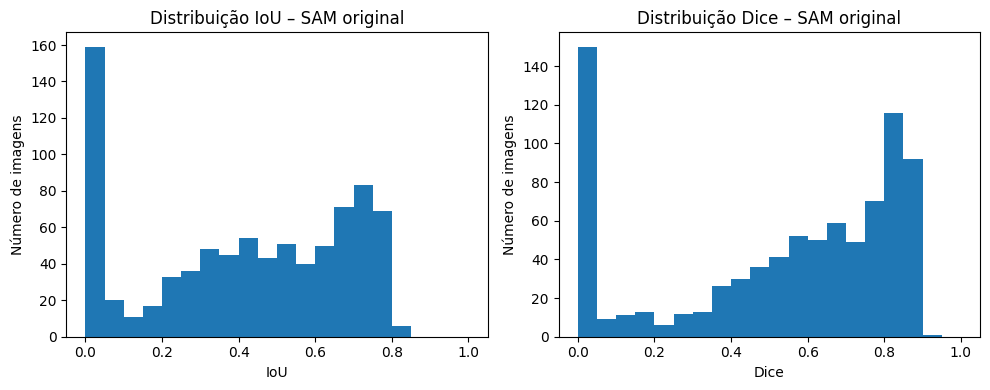

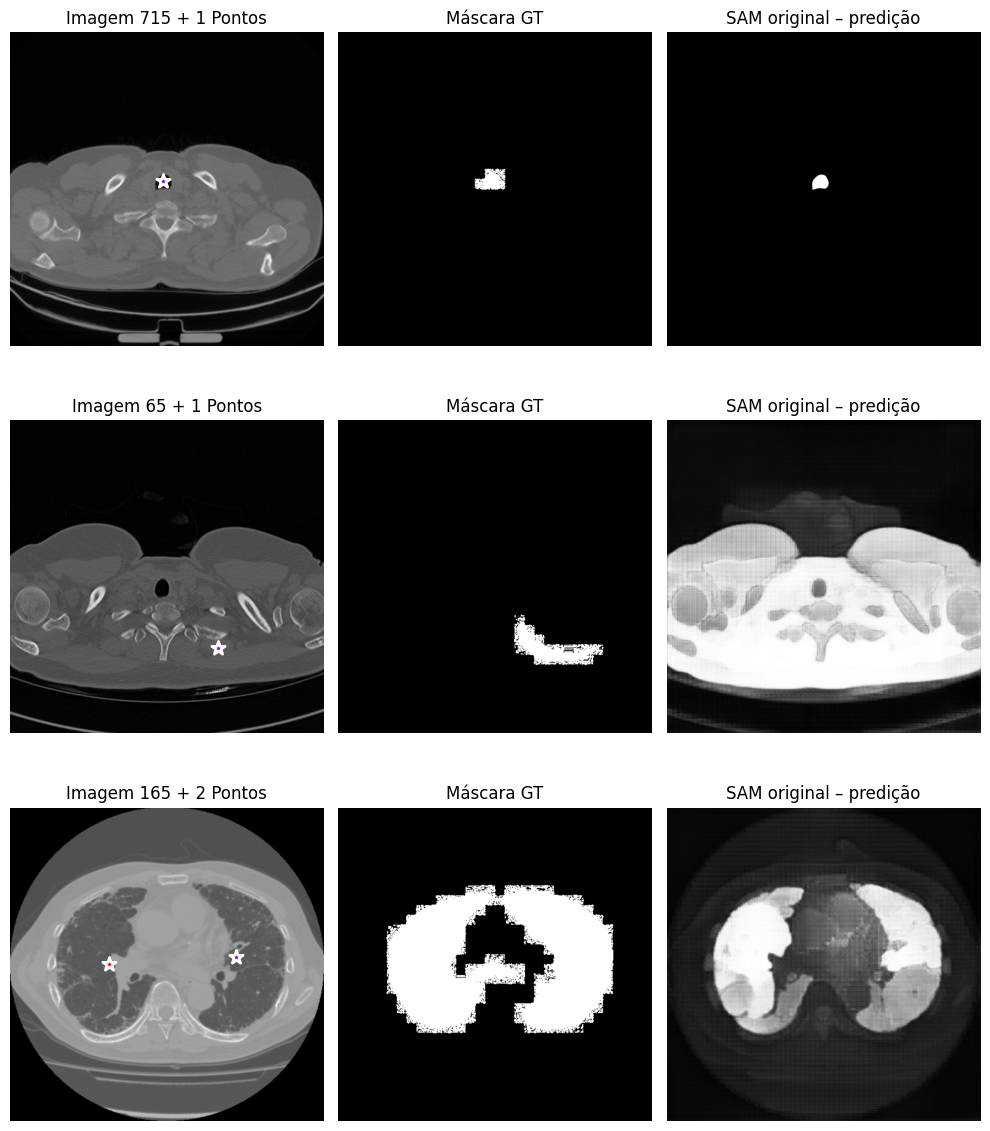

In [12]:
# ============================================================
# ETAPA 3: AVALIAÇÃO DO SAM ORIGINAL (BASELINE)
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Usar o mesmo dataset, mas agora direto com imagens (sem embeddings)
BASELINE_BATCH_SIZE = 2  # pequeno para evitar problemas de memória

val_dataset_baseline = ChestCTDataset(
    val_df,
    config.IMAGES_DIR,
    config.MASKS_DIR,
    transform=None,                # sem augment aqui
    img_size=config.IMG_SIZE,
)

val_loader_full = DataLoader(
    val_dataset_baseline,
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=custom_collate_fn
)

print(f"Nº de imagens de validação (baseline): {len(val_dataset_baseline)}")


# ------------------------------------------------------------
# Função de métricas (IoU e Dice) em batch
# ------------------------------------------------------------
def compute_iou_dice_batch(pred_masks, true_masks, eps: float = 1e-6):
    """
    pred_masks: logits [B, 1, H, W]
    true_masks: binário [B, 1, H, W]
    """
    pred_bin = (torch.sigmoid(pred_masks) > 0.5).float()
    true_bin = (true_masks > 0.5).float()

    intersection = (pred_bin * true_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + true_bin.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (
        pred_bin.sum(dim=(1, 2, 3)) + true_bin.sum(dim=(1, 2, 3)) + eps
    )
    return iou, dice


# ------------------------------------------------------------
# Avaliação do SAM original, processando UMA imagem por vez
# (dentro de cada batch) para evitar o bug de dimensão
# ------------------------------------------------------------
from segment_anything import sam_model_registry

@torch.no_grad()
def evaluate_sam_baseline(dataloader, device, model_type, checkpoint_path):
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    sam.eval()

    all_iou = []
    all_dice = []

    pbar = tqdm(dataloader, desc="Baseline (SAM original)", unit="batch")
    for batch in pbar:
        images = batch["image"].to(device)              # [B, 3, H, W] já pré-processadas
        points_list = [p.to(device) for p in batch["points"]]  # lista de [N_i, 2]
        point_labels_list = [l.to(device) for l in batch["point_labels"]]  # lista de [N_i]
        gt_masks = batch["ground_truth_mask"].to(device)  # [B, 1, H, W]

        B = images.shape[0]
        pred_list = []

        for i in range(B):
            img = images[i:i+1]                # [1, 3, H, W]
            points = points_list[i].unsqueeze(0)  # [1, N, 2]
            labels = point_labels_list[i].unsqueeze(0)  # [1, N]

            # 1) Image encoder
            img_emb = sam.image_encoder(img)

            # 2) Prompt encoder com múltiplos pontos
            sparse_embeddings, dense_embeddings = sam.prompt_encoder(
                points=(points, labels),
                boxes=None,
                masks=None,
            )

            # 3) Mask decoder
            low_res_masks, _ = sam.mask_decoder(
                image_embeddings=img_emb,
                image_pe=sam.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            # 4) Upsample para o mesmo tamanho da máscara ground-truth
            masks_up = F.interpolate(
                low_res_masks,
                size=gt_masks.shape[-2:],  # (H, W) das máscaras GT já redimensionadas/pad
                mode="bilinear",
                align_corners=False,
            )

            pred_list.append(masks_up)

        pred_masks = torch.cat(pred_list, dim=0)  # [B, 1, H, W]

        # Métricas do batch
        iou, dice = compute_iou_dice_batch(pred_masks, gt_masks)
        all_iou.extend(iou.cpu().numpy().tolist())
        all_dice.extend(dice.cpu().numpy().tolist())

        pbar.set_postfix({
            "IoU": float(np.mean(all_iou)),
            "Dice": float(np.mean(all_dice)),
        })

    mean_iou = float(np.mean(all_iou))
    mean_dice = float(np.mean(all_dice))

    return mean_iou, mean_dice, all_iou, all_dice


# ------------------------------------------------------------
# Rodar avaliação baseline
# ------------------------------------------------------------
baseline_val_iou, baseline_val_dice, baseline_iou_list, baseline_dice_list = evaluate_sam_baseline(
    val_loader_full,
    config.DEVICE,
    config.MODEL_TYPE,
    config.CHECKPOINT_PATH,
)

print("\n========== BASELINE – SAM ORIGINAL ==========")
print(f"Val IoU médio :  {baseline_val_iou:.4f}")
print(f"Val Dice médio: {baseline_val_dice:.4f}")


# ------------------------------------------------------------
# Plots: histogramas das métricas
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(baseline_iou_list, bins=20, range=(0, 1))
plt.title("Distribuição IoU – SAM original")
plt.xlabel("IoU")
plt.ylabel("Número de imagens")

plt.subplot(1, 2, 2)
plt.hist(baseline_dice_list, bins=20, range=(0, 1))
plt.title("Distribuição Dice – SAM original")
plt.xlabel("Dice")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualização qualitativa de alguns exemplos
# ------------------------------------------------------------
import random

@torch.no_grad()
def visualize_sam_baseline_examples(dataset, device, model_type, checkpoint_path, num_examples=3):
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    sam.eval()

    num_examples = min(num_examples, len(dataset))
    indices = random.sample(range(len(dataset)), num_examples)

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)  # garantia de 2D

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        image = sample["image"].unsqueeze(0).to(device)          # [1,3,H,W]
        points = sample["points"].unsqueeze(0).to(device)  # [1, N, 2]
        point_labels = sample["point_labels"].unsqueeze(0).to(device)  # [1, N]
        gt_mask = sample["ground_truth_mask"].squeeze(0).cpu().numpy()  # [H,W]

        # Forward no SAM
        img_emb = sam.image_encoder(image)
        sparse_embeddings, dense_embeddings = sam.prompt_encoder(
            points=(points, point_labels), boxes=None, masks=None
        )
        low_res_masks, _ = sam.mask_decoder(
            image_embeddings=img_emb,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        pred_up = F.interpolate(
            low_res_masks,
            size=gt_mask.shape,
            mode="bilinear",
            align_corners=False,
        )
        pred_np = torch.sigmoid(pred_up)[0, 0].cpu().numpy()

        # Reconstruir imagem (des-normalizar) só para visualização
        img_tensor = sample["image"]  # [3, H, W]
        pm = dataset.pixel_mean
        ps = dataset.pixel_std
        img_denorm = (img_tensor * ps + pm).permute(1, 2, 0).cpu().numpy()
        img_denorm = np.clip(img_denorm, 0, 255).astype(np.uint8)

        # Plot
        axes[row, 0].imshow(img_denorm)
        # Marca todos os pontos na imagem com cores diferentes
        points_xy = sample["points"].cpu().numpy()  # [N, 2]
        colors = plt.cm.rainbow(np.linspace(0, 1, len(points_xy)))
        for pt_idx, (point_xy, color) in enumerate(zip(points_xy, colors)):
            axes[row, 0].scatter(point_xy[0], point_xy[1], c=[color], s=100, marker='*',
                               edgecolors='white', linewidths=2, label=f'P{pt_idx+1}')
        axes[row, 0].set_title(f"Imagem {idx} + {len(points_xy)} Pontos")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_mask, cmap="gray")
        axes[row, 1].set_title("Máscara GT")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_np, cmap="gray")
        axes[row, 2].set_title("SAM original – predição")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Rodar visualização de 3 exemplos
visualize_sam_baseline_examples(
    val_dataset_baseline,
    config.DEVICE,
    config.MODEL_TYPE,
    config.CHECKPOINT_PATH,
    num_examples=3,
)

# Libera memória da GPU do SAM baseline (importante antes do fine-tuning)
torch.cuda.empty_cache()

Treinando em device = cuda
Total params: 93,882,928
Trainable params (LoRA only): 147,456
  - LoRA in transformers: 147,456
Trainable: 0.16%

Epoch 1/5
Total params: 93,882,928
Trainable params (LoRA only): 147,456
  - LoRA in transformers: 147,456
Trainable: 0.16%

Epoch 1/5


Train Loss: 0.6156 | Train IoU: 0.3887 | Train Dice: 0.4999
Val   Loss: 0.5354 | Val   IoU: 0.4208 | Val   Dice: 0.5325 | LR: 1.00e-04 | Tempo época: 1.75 min
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 2/5
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 2/5


Train Loss: 0.5492 | Train IoU: 0.3926 | Train Dice: 0.5058
Val   Loss: 0.4896 | Val   IoU: 0.4212 | Val   Dice: 0.5336 | LR: 1.00e-04 | Tempo época: 1.74 min
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 3/5
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 3/5


Train Loss: 0.5142 | Train IoU: 0.4079 | Train Dice: 0.5206
Val   Loss: 0.4418 | Val   IoU: 0.4605 | Val   Dice: 0.5692 | LR: 1.00e-04 | Tempo época: 1.74 min
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 4/5
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 4/5


Train Loss: 0.4408 | Train IoU: 0.4412 | Train Dice: 0.5484
Val   Loss: 0.3848 | Val   IoU: 0.4942 | Val   Dice: 0.5969 | LR: 1.00e-04 | Tempo época: 1.74 min
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 5/5
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Epoch 5/5


Train Loss: 0.3927 | Train IoU: 0.4809 | Train Dice: 0.5865
Val   Loss: 0.3408 | Val   IoU: 0.5280 | Val   Dice: 0.6274 | LR: 1.00e-04 | Tempo época: 1.74 min
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Treinamento concluído! Tempo total aproximado: 8.81 minutos

Carregando melhor modelo salvo de checkpoints/best_model_full.pth para avaliação final...
✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)

Treinamento concluído! Tempo total aproximado: 8.81 minutos

Carregando melhor modelo salvo de checkpoints/best_model_full.pth para avaliação final...



========== RESUMO ==========
SAM ORIGINAL (baseline)  - Val IoU: 0.4157, Val Dice: 0.5300
SAM + LoRA (fine-tuned)  - Test Loss: 0.3302, Test IoU: 0.5485, Test Dice: 0.6591


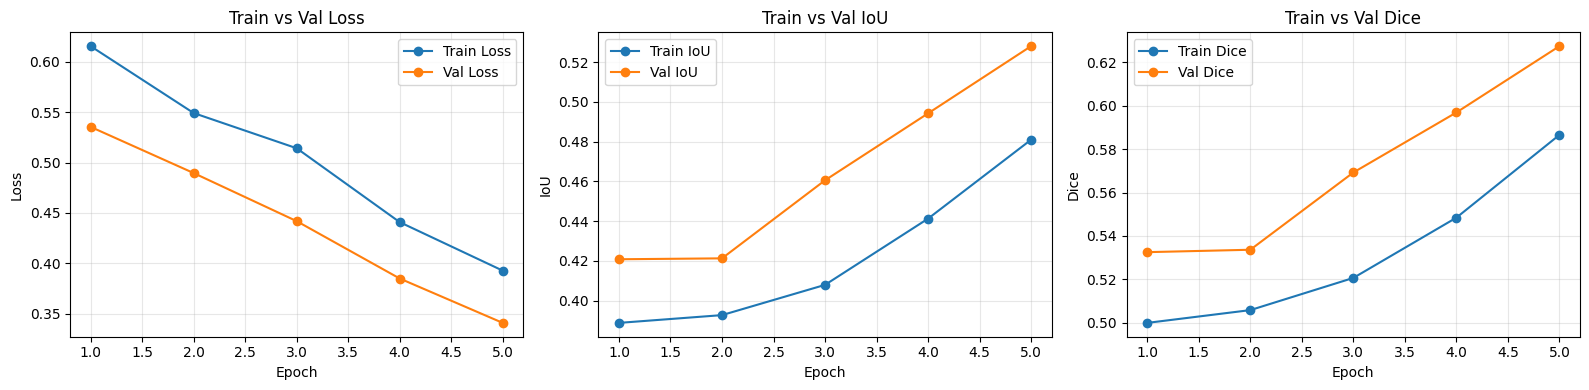

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

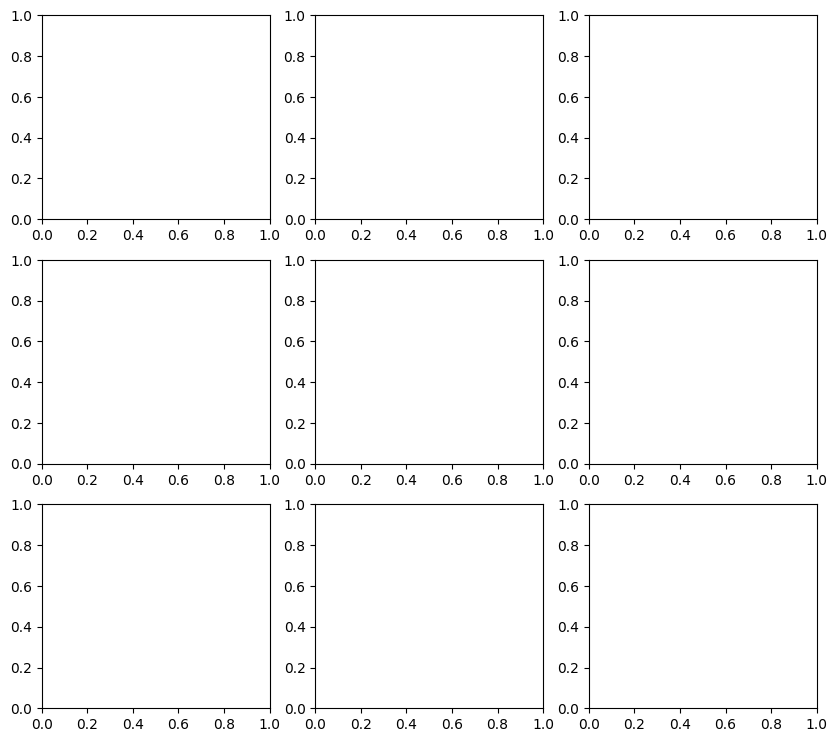

In [13]:
# ============================================================
# ETAPA 4 (NOVA): Treinamento do SAM+LoRA (com checkpoint)
# ============================================================

os.makedirs(config.SAVE_DIR, exist_ok=True)

BEST_MODEL_FULL_PATH = os.path.join(config.SAVE_DIR, "best_model_full.pth")
BEST_LORA_PATH       = os.path.join(config.SAVE_DIR, "best_lora_sam.pth")
CHECKPOINT_LAST_PATH = os.path.join(config.SAVE_DIR, "checkpoint_last.pth")
HISTORY_PATH         = os.path.join(config.SAVE_DIR, "training_history.pt")

device = config.DEVICE
print(f"Treinando em device = {device}")

# ---------- Flags de controle ----------
RESUME_TRAINING = True        # tenta retomar se checkpoint_last existir
SKIP_TRAINING_IF_BEST_EXISTS = False  # se True e best_model_full existir, pula treino


# ---------- Preparar modelo, otimizador, scheduler, losses ----------
model = SAMLoRAModel(config.MODEL_TYPE, config.CHECKPOINT_PATH).to(device)

dice_loss = DiceLoss()
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
loss_fns = [dice_loss, focal_loss]

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
    "lr": [],
}

best_val_loss = float("inf")
best_val_iou = 0.0
best_val_dice = 0.0
patience_counter = 0
start_epoch = 0

# ---------- Tentar retomar de checkpoint ----------
if RESUME_TRAINING and os.path.exists(CHECKPOINT_LAST_PATH):
    print(f"⚠ Encontrado checkpoint em {CHECKPOINT_LAST_PATH}, carregando para retomar treino...")
    ckpt = torch.load(CHECKPOINT_LAST_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    history = ckpt["history"]
    best_val_loss = ckpt["best_val_loss"]
    best_val_iou = ckpt["best_val_iou"]
    best_val_dice = ckpt["best_val_dice"]
    patience_counter = ckpt["patience_counter"]
    start_epoch = ckpt["epoch"] + 1
    print(f"Retomando a partir da época {start_epoch+1}/{config.NUM_EPOCHS}")

# ---------- Se quiser pular treino se já tiver best model salvo ----------
if SKIP_TRAINING_IF_BEST_EXISTS and os.path.exists(BEST_MODEL_FULL_PATH):
    print(f"✓ Modelo já treinado encontrado em {BEST_MODEL_FULL_PATH}. Pulando treino.")
else:
    total_start_time = time.time()

    for epoch in range(start_epoch, config.NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
        epoch_start_time = time.time()

        train_loss, train_iou, train_dice = train_one_epoch(
            model, train_loader, optimizer, loss_fns, device
        )
        val_loss, val_iou, val_dice = eval_one_epoch(
            model, val_loader, loss_fns, device, desc="Val"
        )

        # LR atual
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)

        # Atualizar histórico
        history["train_loss"].append(train_loss)
        history["train_iou"].append(train_iou)
        history["train_dice"].append(train_dice)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_dice"].append(val_dice)
        history["lr"].append(current_lr)

        epoch_time_min = (time.time() - epoch_start_time) / 60.0

        print(
            f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | Train Dice: {train_dice:.4f}\n"
            f"Val   Loss: {val_loss:.4f} | Val   IoU: {val_iou:.4f} | Val   Dice: {val_dice:.4f} | "
            f"LR: {current_lr:.2e} | Tempo época: {epoch_time_min:.2f} min"
        )

        # Salvar checkpoint "last" (para retomar treino se o runtime cair)
        ckpt_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history,
            "best_val_loss": best_val_loss,
            "best_val_iou": best_val_iou,
            "best_val_dice": best_val_dice,
            "patience_counter": patience_counter,
        }
        torch.save(ckpt_state, CHECKPOINT_LAST_PATH)
        torch.save(history, HISTORY_PATH)

        # Checar se é o melhor modelo até agora
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_iou = val_iou
            best_val_dice = val_dice
            patience_counter = 0

            # Salvar modelo completo + somente LoRA
            torch.save(model.state_dict(), BEST_MODEL_FULL_PATH)
            # Se sua classe tiver esses métodos, ótimo; se não, basta usar o state_dict acima
            if hasattr(model, "save_lora_weights"):
                model.save_lora_weights(BEST_LORA_PATH)

            print("✓ Novo melhor modelo salvo (best_model_full.pth / best_lora_sam.pth)")
        else:
            patience_counter += 1
            print(f"Sem melhora na val_loss. patience_counter = {patience_counter}")

        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print("Early stopping acionado.")
            break

    total_time_min = (time.time() - total_start_time) / 60.0
    print(f"\nTreinamento concluído! Tempo total aproximado: {total_time_min:.2f} minutos")

# ---------- Carregar melhor modelo completo para avaliação ----------
if os.path.exists(BEST_MODEL_FULL_PATH):
    print(f"\nCarregando melhor modelo salvo de {BEST_MODEL_FULL_PATH} para avaliação final...")
    best_state = torch.load(BEST_MODEL_FULL_PATH, map_location=device)
    model.load_state_dict(best_state)
else:
    print("⚠ ATENÇÃO: best_model_full.pth não encontrado, usando estado atual do modelo.")

# ---------- Avaliar no conjunto de teste ----------
test_loss, test_iou, test_dice = eval_one_epoch(
    model, test_loader, loss_fns, device, desc="Test"
)

print("\n========== RESUMO ==========")
print(f"SAM ORIGINAL (baseline)  - Val IoU: {baseline_val_iou:.4f}, Val Dice: {baseline_val_dice:.4f}")
print(f"SAM + LoRA (fine-tuned)  - Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test Dice: {test_dice:.4f}")

# ---------- Gráficos de métricas ----------
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU
axes[1].plot(epochs_range, history["train_iou"], label="Train IoU", marker="o")
axes[1].plot(epochs_range, history["val_iou"],   label="Val IoU",   marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].set_title("Train vs Val IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Dice
axes[2].plot(epochs_range, history["train_dice"], label="Train Dice", marker="o")
axes[2].plot(epochs_range, history["val_dice"],   label="Val Dice",   marker="o")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Dice")
axes[2].set_title("Train vs Val Dice")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Visualizações qualitativas do modelo fine-tuned ----------
visualize_predictions(
    dataset=val_dataset,
    device=device,
    model=model,
    predict_fn=predict_mask_lora,
    title_prefix="SAM + LoRA (Val)",
    num_examples=3,
)

visualize_predictions(
    dataset=test_dataset,
    device=device,
    model=model,
    predict_fn=predict_mask_lora,
    title_prefix="SAM + LoRA (Test)",
    num_examples=3,
)


Total params: 93,882,928
Trainable params (LoRA only): 147,456
  - LoRA in transformers: 147,456
Trainable: 0.16%
Carregando modelo fine-tuned de checkpoints/best_model_full.pth


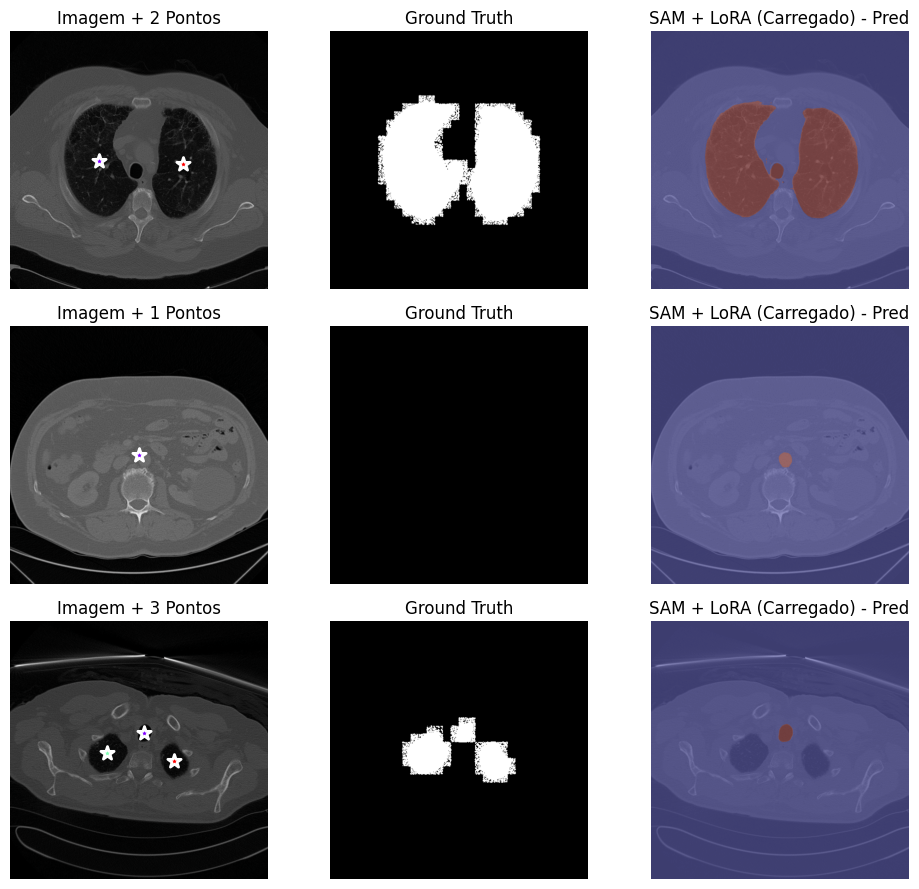

In [18]:
# ============================================================
# ETAPA 5 (Opcional): Carregar modelo SAM+LoRA já treinado
# ============================================================

BEST_MODEL_FULL_PATH = os.path.join(config.SAVE_DIR, "best_model_full.pth")
device = config.DEVICE

model_ft = SAMLoRAModel(config.MODEL_TYPE, config.CHECKPOINT_PATH).to(device)

if os.path.exists(BEST_MODEL_FULL_PATH):
    print(f"Carregando modelo fine-tuned de {BEST_MODEL_FULL_PATH}")
    state = torch.load(BEST_MODEL_FULL_PATH, map_location=device)
    model_ft.load_state_dict(state)
    model_ft.to(device)
    model_ft.eval()
else:
    print("⚠ best_model_full.pth não encontrado. Verifique se o treino já foi executado e se o caminho SAVE_DIR está correto.")

# Exemplo: visualizar algumas predições no conjunto de teste
visualize_predictions(
    dataset=test_dataset,
    device=device,
    model=model_ft,
    predict_fn=predict_mask_lora,
    title_prefix="SAM + LoRA (Carregado)",
    num_examples=3,
)
